# CLIP-ReID ViT-B/16 — вариант 2: контролируемый Optuna HPO

**Run All**: 12 конфигураций ×15 эпох → top-4 до35 → top-2 до60 → победитель ещё на двух seed, если улучшение к варианту1 ≥0,5 п.п.

Это development-поиск на прежнем чистом inner split. Test, внешние calibration/validation, MVP и ручные маски не участвуют и не меняются. Вариант1 и его лучшие веса сохраняются.

Ориентир: **22 часа поиска + около9 часов дополнительных seed**, если будет пройден порог. Время зависит от нагрузки. Не закрывайте крышку Mac; держите питание подключённым. Ручную разметку в HTML можно выполнять параллельно — она не запускает обучение.

Подробности и источники: [README.md](README.md).

## 1. Окружение

Используйте существующий kernel из `.venv`; дополнительные зависимости не нужны. Если окружение ещё не подготовлено, из корня репозитория:

```bash
uv pip install --python .venv/bin/python -r requirements-train.txt
uv pip check --python .venv/bin/python
caffeinate -i .venv/bin/python -m jupyter lab
```

`caffeinate -i` препятствует автоматическому сну при бездействии, но не гарантирует работу с закрытой крышкой.

После прерывания: **Restart Kernel → Run All**, не удаляйте JSON, SQLite или checkpoints. Конфигурацию завершённого/частичного эксперимента менять нельзя: для других настроек создайте новую папку варианта.

In [1]:
import json
import os
import sys
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'backend').exists():
    ROOT = ROOT.parent
assert (ROOT / 'backend').exists(), 'Не найден корень Car-classification-MSK'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from backend.core import DATASET
from training.pipeline import ensure_splits, select_device
from training.clip_experiment import prepare_protocol
from training.clip_hpo import (SearchPlan, SOURCE, VARIANT, experiment_lock, load_references,
                               require_disk, run_experiment, technical_smoke)
from training.stage6 import write_json

VARIANT_DIR = VARIANT
RESULTS_DIR = VARIANT_DIR / 'results'
WEIGHTS_DIR = VARIANT_DIR / 'weights'
PLAN = SearchPlan(
    trials=12, screen_epochs=15, top_k=4, promotion_epochs=35,
    finalists=2, final_epochs=60, prune_after_epoch=12,
    extra_seeds=(20260916, 20260917), confirmation_min_gain=0.005,
)
RUN_SMOKE = True
RUN_HPO = True
ALLOW_CPU = False
DEVICE = select_device()
PLAN.validate()
print('Python:', sys.executable)
print('Device:', DEVICE, '| torch:', torch.__version__)
print('Папка:', VARIANT_DIR)
print(json.dumps(asdict(PLAN), ensure_ascii=False, indent=2))
if DEVICE.type == 'cpu' and not ALLOW_CPU:
    raise RuntimeError('MPS/CUDA не найдены. Не запускаем многочасовой CLIP HPO на CPU.')

Python: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/.venv/bin/python
Device: mps | torch: 2.14.0
Папка: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/CLIP-ReID-ViT-B-16/variant_02_hpo
{
  "trials": 12,
  "screen_epochs": 15,
  "top_k": 4,
  "promotion_epochs": 35,
  "finalists": 2,
  "final_epochs": 60,
  "prune_after_epoch": 12,
  "extra_seeds": [
    20260916,
    20260917
  ],
  "confirmation_min_gain": 0.005
}


## 2. Разбиение и контрольные результаты

Обучение — только inner-train из organiser train.csv. Одна и та же inner-validation используется для всех trials и seed. Идентичности и точные исходные кадры не пересекаются между train/validation. Проверяются хэши данных, кода, исходных весов и evaluator.

Контроль: CLIP variant1 — 71,82%, чистый inner-trained OSNet —77,87% raw mAP@10. Эти значения загружаются из проверенных отчётов, не прописываются как результаты нового обучения.

In [2]:
with experiment_lock(VARIANT_DIR):
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
    fresh = not (RESULTS_DIR / 'manifest.json').exists()
    free = require_disk(VARIANT_DIR, max(26, 1.7 * (PLAN.trials + len(PLAN.extra_seeds)) + 3) if fresh else 3)
    rows, split = ensure_splits(DATASET)
    protocol = prepare_protocol(rows, split, RESULTS_DIR, DATASET)
    references = load_references(protocol)
print('Свободно GiB:', round(free, 1))
print('Train IDs:', len(protocol['inner']['train']), '| Validation IDs:', len(protocol['inner']['validation']))
print(json.dumps(references, ensure_ascii=False, indent=2))

Свободно GiB: 29.6
Train IDs: 741 | Validation IDs: 184
{
  "clip_variant_1": 0.7182085782158669,
  "clean_osnet": 0.7787153115214339,
  "protocol": "47ae5c0c79d5cedc906a07bd06258eaa2ed8e298ab40acda449e52f5a80fa5a7",
  "selection_metric": "organizer raw inner mAP@10",
  "outer_test_used": false
}


## 3. Короткая техническая проверка

Один настоящий batch P16/K2: загрузка исходных весов, разные LR головы и энкодера, forward/backward, конечность градиентов и Adam step. Модель после проверки уничтожается; ни один trial не стартует с её изменённых весов.

Новые признаки диагностики: accuracy головы768, головы512 и image-to-text классификации. Это train-диагностика, не retrieval-качество.

In [3]:
if RUN_SMOKE:
    with experiment_lock(VARIANT_DIR):
        smoke = technical_smoke(rows, protocol, DEVICE, SOURCE, DATASET)
        write_json(RESULTS_DIR / 'technical_smoke.json', smoke)
    print(json.dumps(smoke, ensure_ascii=False, indent=2))

{
  "device": "mps",
  "batch": 32,
  "layout": "16x2",
  "head_lr_multiplier": 10,
  "backward_and_adam_checked": true,
  "seconds": 2.2190727920096833,
  "diagnostics": {
    "loss": 21.32392692565918,
    "id_loss": 13.214605331420898,
    "triplet": 1.1072096824645996,
    "image_text": 7.002110958099365,
    "accuracy_head_768": 0.0,
    "accuracy_head_512": 0.0,
    "accuracy_image_text": 0.0
  },
  "not_a_quality_result": true,
  "saved_training_weights": false
}


## 4. Полный поиск и автоматическое продолжение

Перебираются encoder LR 2e-6…2e-5, head multiplier1/5/10/20, weight decay1e-6…1e-3, P8/K4 или P16/K2 и ID-loss weight0.25/0.5/1. Четыре начальные конфигурации — baseline и отдельные изменения LR головы, P/K, веса ID loss. Остальные предлагает Optuna TPE.

Промпты первого seed переиспользуются **только после проверки совместимости**. Новые seed обучают свои промпты. Исходный vehicle checkpoint, размер256×256, BNNeck, Adam, Triplet+image-text loss и аугментации фиксированы.

Отсев не раньше завершения12-й эпохи и не раньше четырёх полных trials. Горизонт scheduler всегда60: warmup10, уменьшения LR на30/50. Продолжение до35/60 сохраняет оптимизатор, историю и лучший checkpoint.

Порог дополнительных seed0.005 = **0,5 процентного пункта** относительно CLIP variant1; это ограничение бюджета, не доказательство значимости. При непройденном пороге поиск завершается отчётом. Test/outer evaluation и подключение к MVP не запускаются автоматически.

**Следующая ячейка — длительная.** В ней выводятся эпоха, оставшиеся эпохи, время эпохи, ETA этапа и оценка оставшегося поиска. Текущее состояние также доступно в `results/progress.json` из другого окна.

In [4]:
if RUN_HPO:
    report = run_experiment(rows, split, DEVICE, variant=VARIANT_DIR, plan=PLAN,
                            source=SOURCE, dataset=DATASET, allow_cpu=ALLOW_CPU)
else:
    summary_path = RESULTS_DIR / 'experiment_summary.json'
    report = json.loads(summary_path.read_text()) if summary_path.exists() else None
    print('Обучение выключено; завершённый отчёт найден:', report is not None)
if report:
    print('Победитель:', report['winner']['name'])
    print('Лучший mAP@10:', report['winner']['best']['validation']['mAP_at_10'])
    print('Результаты seed:', report['seed_scores'])
    print('Подтверждение:', report['confirmation'])

Свободно 29.6 GiB. Аудит исходных данных и разделения…


[I 2026-09-19 09:43:41,502] A new study created in RDB with name: clip_reid_variant_02



trial_000: обучение/продолжение до 15 эпох, seed=20260915


CLIP embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

CLIP image 1/60:   0%|          | 0/144 [00:00<?, ?it/s]

...

CLIP embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

trial_011_seed_20260917: эпоха 59/60 (предел 60), осталось 1 | эпоха 00:04:16 | ETA этапа 00:04:15 | mAP@10 73.8118%, best 75.6372%
ETA оставшегося поиска ≤ 00:00:00; дополнительные seed, если пройдёт порог: ещё ≈ 00:44:13


CLIP image 60/60:   0%|          | 0/144 [00:00<?, ?it/s]

CLIP embeddings:   0%|          | 0/44 [00:00<?, ?it/s]

trial_011_seed_20260917: эпоха 60/60 (предел 60), осталось 0 | эпоха 00:04:16 | ETA этапа 00:00:00 | mAP@10 74.2500%, best 75.6372%
ETA оставшегося поиска ≤ 00:00:00; дополнительные seed, если пройдёт порог: ещё ≈ 00:40:00
Победитель: trial_011
Лучший mAP@10: 0.7579937371774106
Результаты seed: [0.7579937371774106, 0.7523329014145341, 0.7563723769931253]
Подтверждение: {'run': True, 'gain_over_variant_1': 0.039785158961543665, 'minimum_gain': 0.005, 'reason': 'Budget gate on inner validation, not statistical significance'}


## 5. Сводка и графики

Выбор по raw inner mAP@10. Старые результаты variant1/OSNet показаны только на том же протоколе. Дополнительные seed проверяют случайность обучения, но не независимость от конкретного разбиения. Не выбираем «удачный seed» вместо отчёта обо всех повторах.

# CLIP-ReID — HPO results

Только raw inner mAP@10. Outer/test не использованы.

- CLIP variant 1: 71.8209%.
- Чистый OSNet-контроль: 77.8715%.
- Победитель поиска: trial_011, 75.7994%, эпоха 33.
- Seed mAP@10: 75.7994%, 75.2333%, 75.6372%.
- Среднее: 75.5566%; std (population): 0.2380%.
- Дополнительные seed выполнены: 2.

Checkpoint каждого seed выбран по той же validation; это не независимый тест.
Повторы seed не проверяют устойчивость к выбору разбиения.
Порог отказа, реранкинг, номерные маски и MVP не изменены.
Следующий шаг — ручная разметка и парный аудит анонимизации, а не автоматическая замена MVP.


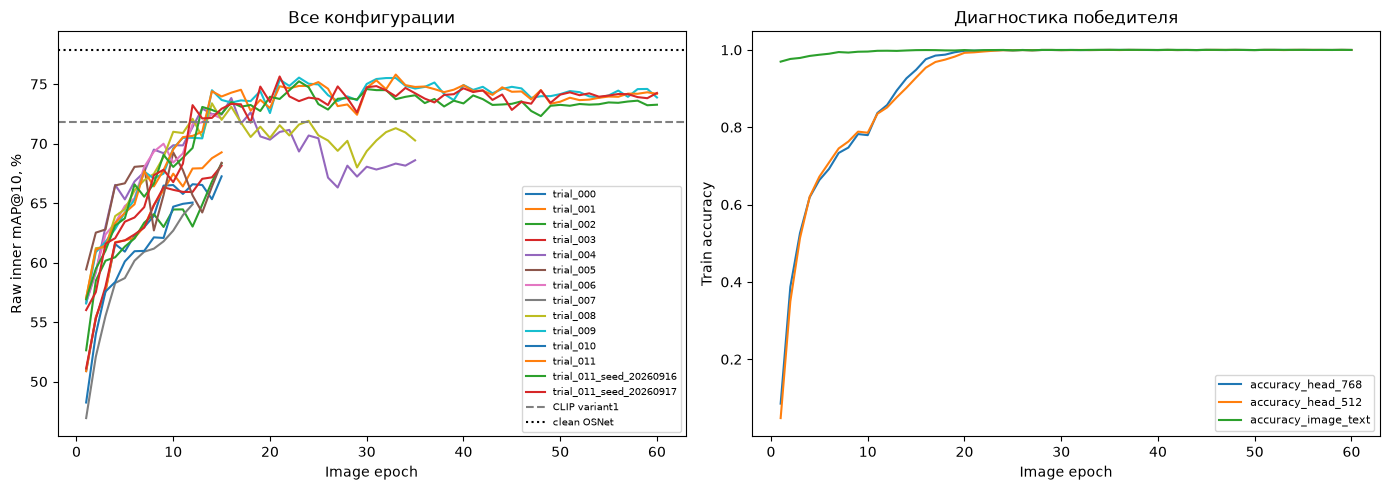

In [5]:
summary_path = RESULTS_DIR / 'RESULTS.md'
if summary_path.exists():
    display(Markdown(summary_path.read_text()))

history_paths = sorted((RESULTS_DIR / 'runs').glob('*/image_history.json'))
if history_paths:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for path in history_paths:
        history = json.loads(path.read_text())
        if not history:
            continue
        axes[0].plot([r['epoch'] for r in history],
                     [100*r['validation']['mAP_at_10'] for r in history], label=path.parent.name)
    axes[0].axhline(100*references['clip_variant_1'], color='gray', linestyle='--', label='CLIP variant1')
    axes[0].axhline(100*references['clean_osnet'], color='black', linestyle=':', label='clean OSNet')
    axes[0].set(xlabel='Image epoch', ylabel='Raw inner mAP@10, %', title='Все конфигурации')
    axes[0].legend(fontsize=7)
    if report:
        history = json.loads((RESULTS_DIR / 'runs' / report['winner']['name'] / 'image_history.json').read_text())
        for metric in ['accuracy_head_768', 'accuracy_head_512', 'accuracy_image_text']:
            axes[1].plot([r['epoch'] for r in history], [r['train'][metric] for r in history], label=metric)
        axes[1].set(xlabel='Image epoch', ylabel='Train accuracy', title='Диагностика победителя')
        axes[1].legend(fontsize=8)
    plt.tight_layout()

## 6. Что прислать для анализа и что делать с разметкой

Основные результаты: `results/experiment_summary.json`, `study_summary.json`, `stage2_top4_summary.json`, `stage3_top2_summary.json`, истории в `results/runs/` и `RESULTS.md`.

Лучшие веса каждого запуска: `weights/<trial>/image_best.pt`; последний checkpoint с оптимизатором: `image_last.pt`. У продвинутых кандидатов сохраняются лучшие веса предыдущего этапа `best_after_015.pt` / `best_after_035.pt`.

Параллельно можно размечать уже подготовленные изображения в HTML-инструменте аудита OSNet. Не редактируйте сами изображения/CSV или учебный код во время HPO. Запуск второго обучения либо GPU-аудита параллельно будет конкурировать за память MPS; сама HTML-разметка — нет.

После завершения — анализ HPO и парный аудит настоящих масок. Этот notebook не меняет MVP, не экспортирует случайный checkpoint в рабочую модель и не делает commit/push.